## Notebook to Analyze Simulations
A study on higher-order resonances in the TRAPPIST-1 system, based on Keller et al. (2026). We want to answer the questions:
- Can Type I migration alone lead to the observed resonant structure?
- How do initial conditions and disk migration parameters map to final resonant outcomes?
More formally, how can I accurately construct a mapping $\mathbf{f}(\mathbf{p}) = \mathbf{o}$ (where $\mathbf{p}$ represents the initial parameters and $\mathbf{o}$ represents the outcome classification).

#### Imports and Units

In [5]:
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pickle as pkl
import trappist1_sim as t1
import mmr_id
from time import time
from astropy import units as u
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Unit conversions
AU = u.AU.to(u.cm)    
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

#### Load dataset and get general information
Once simulations have been saved, the following code can be used to look at the evolution of orbital elements and period ratios, as well as checking whether there is resonance in the final configuration.

In [27]:
# Process data for any given dataset
dataset_ids = [15]
dataset_id = 15

all_outcomes = []
for dataset_id in dataset_ids:
    outcome_file = f"../sim_results/dataset{dataset_id}/outcomes.pkl"
    with open(outcome_file, "rb") as f:
        sim_outcomes = pkl.load(f)
    all_outcomes += sim_outcomes
    
n_sims = len(all_outcomes)

columns = [
    "sim_id",
    "m_vals",
    "r_vals",
    "m_star",
    "r_star",
    "initial_P_ratios"
]

outcome_df = pd.DataFrame(all_outcomes, columns=columns)
outcome_df = outcome_df.sort_values(by='sim_id') 

#### Investigate a specific simulation run & plot it

C_e = 0.1
tau_a_earth = 10000.0


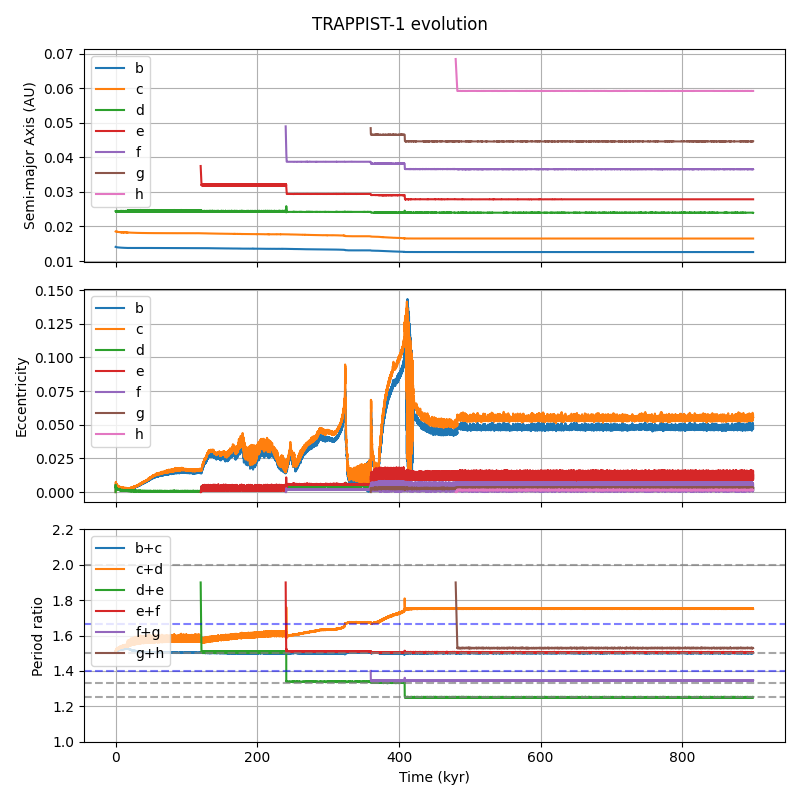

In [30]:
sim_id = 0

base_dir = Path.cwd()
file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"

row = outcome_df.loc[outcome_df["sim_id"] == sim_id].iloc[0]
# print(f"Initial P ratios: {row['initial_P_ratios']} | Sigma_1au: {float(row['Sigma_1au']):.4} | K-factor: {float(row['K_factor']):.4}")

saved_sim = t1.load_simulation_run(file_path)
sim_data = saved_sim[0]
m_star = saved_sim[1]['m_star'] 
planet_names = saved_sim[1]['planet_names']
print(f"C_e = {saved_sim[1]['C_e']}")
print(f"tau_a_earth = {saved_sim[1]['tau_a_earth']}")

planets = {p: sim_data[p] for p in planet_names}

# Example usage
# print(saved_sim[1]['m_star'])
# print(planets['b'][:5])
# print(planets['b']['a'][:5])
# print(planets['b'].attrs["planet_name"])

%matplotlib widget
t1.plot_trappist1(saved_sim)

In [34]:
dataset_id = 15
for sim_id in range(1):
    base_dir = Path.cwd()
    file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"

    # row = outcome_df.loc[outcome_df["sim_id"] == sim_id].iloc[0]
    # print(f"Initial P ratios: {row['initial_P_ratios']} | Sigma_1au: {float(row['Sigma_1au']):.4} | K-factor: {float(row['K_factor']):.4}")

    saved_sim = t1.load_simulation_run(file_path)
    sim_data = saved_sim[0]
    m_star = saved_sim[1]['m_star'] 
    planet_names = saved_sim[1]['planet_names']
    planets = {p: sim_data[p] for p in planet_names}
    print(sim_id)
    print(f"C_e = {saved_sim[1]['C_e']}")
    print(f"tau_a_earth = {saved_sim[1]['tau_a_earth']}")
    print(f"tau_pl = {saved_sim[1]['tau_pl']}")
    print(f"A_a = {saved_sim[1]['A_a']}")
    print(f"A_e = {saved_sim[1]['A_e']}")
    print(mmr_id.check_resonance(m_star, planets['c'], planets['d']))

0
C_e = 0.1
tau_a_earth = 10000.0
tau_pl = 120000.0
A_a = 100
A_e = 40
(7, 4)


(7, 4)
True period ratios: b+c: 1.7505, c+d: 1.2529
p_cd, q_cd, p_de, q_de: 7, 4, 5, 4
Libration amplitude: 148.5 deg


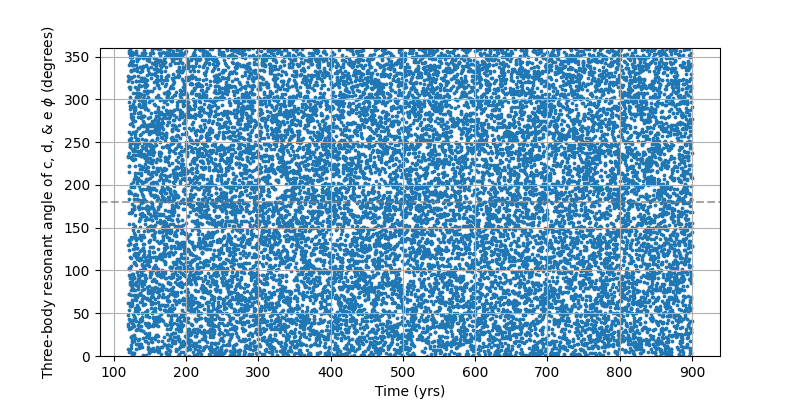

In [ ]:
# mmr_id.plot_libration(m_star, planets['c'], planets['d'])
mmr_id.plot_libration(m_star, planets['c'], planets['d'], planets['e'])

### Plotting Outcomes

#### Small multiples by outcome (3D):

In [ ]:
%matplotlib widget
Sigma_1au = outcome_df["Sigma_1au"].to_numpy()
K_factor = outcome_df["K_factor"].to_numpy()
masses = np.stack(outcome_df["m_vals"])
m_d = masses[:, 2]

log_Sigma = np.log(Sigma_1au.astype(float))
log_K = np.log(K_factor.astype(float))

outcomes = [-1, 0, 1, 2, 3]
color_map = {-1: "C0", 0: "C1", 1: "C2", 2: "C3", 3: "C4"}

fig = plt.figure(figsize=(12, 10))

for i, outcome in enumerate(outcomes):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    mask = (scores == outcome)

    ax.scatter(
        log_Sigma[mask],
        log_K[mask],
        m_d[mask],
        c=color_map[outcome],
        alpha=0.6,
        s=18
    )

    ax.set_title(f"Outcome = {outcome}", fontsize=13, fontweight='bold')
    ax.set_xlabel(r'$\log \Sigma_{1\,au}$', fontsize=9)
    ax.set_ylabel(r'$\log K$', fontsize=9)
    ax.set_zlabel(r'$m_d$', fontsize=9)

    # Keep axis limits consistent across panels
    ax.set_xlim(log_Sigma.min(), log_Sigma.max())
    ax.set_ylim(log_K.min(), log_K.max())
    ax.set_zlim(m_d.min(), m_d.max())

fig.suptitle("Small Multiples by Outcome", fontsize=15, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

#### 2D outcomes plot with all outcomes combined

In [ ]:
%matplotlib widget
fig, ax = plt.subplots()

Sigma_1au = outcome_df["Sigma_1au"].astype(float).to_numpy()
K_factor = outcome_df["K_factor"].astype(float).to_numpy()

color_map = {
    -1: "C0",
     0: "C1",
     1: "C2",
     2: "C3",
     3: "C4"
}

log_sigma = np.log(Sigma_1au)
log_K = np.log(K_factor)

for outcome, color in color_map.items():
    mask = scores == outcome
    ax.scatter(
        log_sigma[mask],
        log_K[mask],
        c=color,
        label=str(outcome),
        alpha=0.6,
        s=10
    )

ax.set_xlabel(r'$\log \Sigma_{1\,au}$')
ax.set_ylabel(r'$\log K$')
ax.set_title("Randomized period ratios")
ax.legend(title="Outcome")

plt.show()

In [ ]:
plot_df = outcome_df.copy()
plot_df["Outcome"] = scores

sns.pairplot(
    plot_df[["Sigma_1au","K_factor","Outcome"]],
    hue="Outcome"
)

In [ ]:
%matplotlib widget

Sigma_1au = outcome_df["Sigma_1au"].to_numpy()
K_factor = outcome_df["K_factor"].to_numpy()
masses = np.stack(outcome_df["m_vals"])
m_d = masses[:, 2]

log_Sigma = np.log(Sigma_1au.astype(float))
log_K = np.log(K_factor.astype(float))

pair_names = ['b/c', 'c/d', 'd/e', 'e/f', 'f/g']

def get_highest_pair(outcome_list):
    """Returns the index of the pair with the highest resonance order, or -1 if incomplete."""
    if outcome_list[0] == -1:
        return -1
    orders = outcome_list[1:]
    if all(o == 0 for o in orders):
        return -1  # no resonance
    return int(np.argmax(orders))

highest_pairs = np.array([get_highest_pair(o) for o in outcome_df["outcome"]])

# Marker shapes for each pair
pair_markers = {-1: 'x', 0: 'o', 1: 's', 2: '^', 3: 'D', 4: 'P'}
pair_labels  = {-1: 'none/incomplete', 0: 'b/c', 1: 'c/d', 2: 'd/e', 3: 'e/f', 4: 'f/g'}

score_values = [-1, 0, 1, 2, 3]
color_map = {-1: "C0", 0: "C1", 1: "C2", 2: "C3", 3: "C4"}

fig = plt.figure(figsize=(12, 10))

for i, score_val in enumerate(score_values):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    score_mask = (scores == score_val)

    for pair_idx, marker in pair_markers.items():
        pair_mask = score_mask & (highest_pairs == pair_idx)
        if pair_mask.sum() == 0:
            continue
        ax.scatter(
            log_Sigma[pair_mask],
            log_K[pair_mask],
            m_d[pair_mask],
            c=color_map[score_val],
            marker=marker,
            alpha=0.6,
            s=18,
            label=pair_labels[pair_idx]
        )

    ax.set_title(f"Outcome = {score_val}", fontsize=13, fontweight='bold')
    ax.set_xlabel(r'$\log \Sigma_{1\,au}$', fontsize=9)
    ax.set_ylabel(r'$\log K$', fontsize=9)
    ax.set_zlabel(r'$m_d$', fontsize=9)
    ax.set_xlim(log_Sigma.min(), log_Sigma.max())
    ax.set_ylim(log_K.min(), log_K.max())
    ax.set_zlim(m_d.min(), m_d.max())

    ax.legend(fontsize=7, loc='upper left', title='highest pair')

fig.suptitle("Small Multiples by Outcome (marker = highest-order resonance pair)", fontsize=13, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

### Checking for sequential resonance capture

In [ ]:
# Check all pairs
results = mmr_id.detect_sequential_capture(saved_sim)
for pair, r in results.items():
    print(f"{pair}: sequential={r['sequential']}, final order={r['final_order']}")
    for desc in r['sequence_description']:
        # print(f"  {desc}")
        pass
# Plot amplitude evolution for nth pair
mmr_id.plot_sequential_capture(saved_sim, pair_idx=1)

In [ ]:
dftest = pd.DataFrame()
dftest['ID'] = range(100)
dftest

### Parameter Study Outcomes

In [ ]:
import matplotlib.patches as mpatches
import math
%matplotlib inline

def plot_param_study_grid(
    values,
    k,
    i=1,
    j=None,
    m=5,
    n=10,
    subplot_labels=None,
    circle_threshold=None,
    figsize=None,
):
    """
    Plot k subplots arranged in an i×j grid, each containing an m×n grid
    of numbers or green circles.

    Parameters
    ----------
    values : list of (k * m * n) numbers
        Flat list. The first m*n values go to subplot 1, next m*n to subplot 2, etc.
    k : int
        Number of subplots.
    i : int, optional
        Number of subplot rows. Default: 1.
        If only i is given (j=None), j is inferred so that i*j >= k.
        If both are None, a roughly square layout is chosen.
    j : int or None, optional
        Number of subplot columns. Inferred from i and k if None.
    m : int, optional
        Number of symbol rows inside each subplot. Default: 5.
    n : int, optional
        Number of symbol columns inside each subplot. Default: 10.
    subplot_labels : list of str or None
        Title for each subplot. Defaults to "Group 1", "Group 2", ...
    circle_threshold : float or None
        Values strictly less than this are drawn as green circles.
        None → always show the number.
    figsize : tuple or None
        Figure size in inches. Auto-computed if None.
    """
    cells_per_subplot = m * n
    expected = k * cells_per_subplot
    assert len(values) == expected, (
        f"Expected {expected} values for k={k} subplots of {m}×{n}, "
        f"but got {len(values)}."
    )

    # Subplot layout
    if j is None:
        j = math.ceil(k / i)
    assert i * j >= k, f"i×j ({i}×{j}) must be >= k ({k})."

    if subplot_labels is None:
        subplot_labels = [f"Group {idx+1}" for idx in range(k)]
    assert len(subplot_labels) >= k, "Need at least k subplot_labels."

    if figsize is None:
        figsize = (4 * j + 1, 3 * i + 0.5)

    # Drawing constants
    CIRCLE_COLOR  = "#27ae60"
    NUMBER_COLOR  = "#2c3e50"
    CIRCLE_RADIUS = 0.35

    fig, axes = plt.subplots(i, j, figsize=figsize,
                             sharex=True, sharey=True,
                             squeeze=False)
    fig.subplots_adjust(wspace=0.35, hspace=0.45)

    for idx in range(i * j):
        row_ax = idx // j
        col_ax = idx % j
        ax = axes[row_ax][col_ax]

        if idx >= k:
            # Hide unused subplot slots
            ax.set_visible(False)
            continue

        chunk = values[idx * cells_per_subplot : (idx + 1) * cells_per_subplot]

        for pos, val in enumerate(chunk):
            col = pos % n            # symbol column (0 … n-1)
            row = pos // n           # symbol row (0 … m-1)
            y   = (m - 1) - row      # flip so row-0 is at the top

            if circle_threshold is not None and val < circle_threshold:
                ax.add_patch(mpatches.Circle(
                    (col, y), radius=CIRCLE_RADIUS,
                    color=CIRCLE_COLOR, zorder=3
                ))
            else:
                ax.text(col, y, str(val),
                        ha="center", va="center",
                        fontsize=max(5, 9 - n // 5),   # shrink text for large n
                        color=NUMBER_COLOR,
                        fontweight="bold", zorder=3)

        # Axes formatting
        ax.set_xlim(-0.6, n - 0.4)
        ax.set_ylim(-0.6, m - 0.4)
        ax.set_xticks(range(n))
        ax.set_yticks(range(m))
        ax.set_xticklabels(range(1, n + 1), fontsize=7)
        ax.set_yticklabels(range(m, 0, -1), fontsize=7)
        ax.tick_params(length=0)
        ax.set_aspect("equal")

        # Light cell grid
        for x in np.arange(-0.5, n, 1):
            ax.axvline(x, color="#cccccc", linewidth=0.6, zorder=1)
        for y in np.arange(-0.5, m, 1):
            ax.axhline(y, color="#cccccc", linewidth=0.6, zorder=1)

        ax.set_title(subplot_labels[idx], fontsize=10, fontweight="bold", pad=6)

        # Only show axis labels on the border subplots
        if row_ax == i - 1 or (idx + j >= k):   # bottom-most visible row
            ax.set_xlabel("Column", fontsize=8)
        if col_ax == 0:
            ax.set_ylabel("Row", fontsize=8)

    fig.suptitle("Symbol Grid", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

import random
K, I, M, N = 3, 5, 10       # K subplots (laid out in I rows), each M rows × N columns
data = [random.randint(0, 99) for _ in range(K * M * N)]

plot_param_study_grid(
    values=data, k=K, i=I, m=M, n=N,
    subplot_labels=[f"tau_pl={120e3+20e3*t:.1e}" for t in range(K)],
    circle_threshold=10,
)

ValueError: not enough values to unpack (expected 4, got 3)